# NB09: Baseline Models

Five baselines for the transfer learning evaluation benchmark.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import expit
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '/Users/dlau/repos/fish-welfare/data/'
OUT_DIR = '/Users/dlau/repos/fish-welfare/ModelSelection/'
np.random.seed(42)
print("Imports OK")

Imports OK


In [2]:
try:
    tgt = pd.read_csv(DATA_DIR + 'nb04_target_features.csv', parse_dates=['date'])
    src = pd.read_csv(DATA_DIR + 'nb04_source_features.csv', parse_dates=['date'])
    print("Loaded nb04 files")
except:
    tgt = pd.read_csv(DATA_DIR + 'nb01_target_daily_features.csv', parse_dates=['date'])
    wq = pd.read_csv(DATA_DIR + 'water_quality.csv')
    target_wq = wq[(wq['region']=='Eluru')&(wq['Type']=='Morning')&(wq['Is follow up']=='No')].copy()
    target_wq['date'] = pd.to_datetime(target_wq['Date of data collection'], format='%m/%d/%Y')
    target_wq['DO'] = pd.to_numeric(target_wq['DO (mg/L)'], errors='coerce')
    daily_out = target_wq.dropna(subset=['DO']).groupby('date').agg(
        n_total=('DO','count'), n_low=('DO',lambda x:(x<3).sum())
    ).reset_index()
    daily_out['frac_low'] = daily_out['n_low']/daily_out['n_total']
    tgt = tgt.merge(daily_out, on='date', how='inner')
    tgt['log_n_ponds'] = np.log1p(tgt['n_total'])
    src = pd.read_csv(DATA_DIR + 'feature_matrix.csv', parse_dates=['date'])

import json
try:
    with open(DATA_DIR + 'nb04_selected_features.json') as f:
        feat_info = json.load(f)
    features = [f for f in feat_info['tgt_available'] if f in tgt.columns]
    src_features = [f for f in feat_info['src_available'] if f in src.columns]
except:
    features = [c for c in tgt.columns if c not in ['date','n_total','n_low','frac_low','bad_day',
                'log_n_ponds','month','season','mean_do','n_ponds']]
    src_features = features

avail_feats = [f for f in features if f in tgt.columns]
all_feats = ['date','n_total','n_low','frac_low'] + avail_feats
tgt_clean = tgt[all_feats].dropna().sort_values('date').reset_index(drop=True)

n = len(tgt_clean)
split_idx = int(n * 0.8)
train = tgt_clean.iloc[:split_idx].copy()
test = tgt_clean.iloc[split_idx:].copy()

tgt_clean['month'] = tgt_clean['date'].dt.month
train['month'] = train['date'].dt.month
test['month'] = test['date'].dt.month

print(f"Train: {len(train)}, Test: {len(test)}")
print(f"Features: {avail_feats}")

Loaded nb04 files
Train: 596, Test: 150
Features: ['month_sin', 'night_precip_sum', 'precip_2d_sum', 'doy_cos', 'night_wind_min']


## Metric Functions

In [3]:
def brier_score(y_true, y_pred):
    return np.mean((np.clip(y_pred, 1e-7, 1-1e-7) - y_true)**2)

def log_loss(y_true, y_pred, eps=1e-7):
    yp = np.clip(y_pred, eps, 1-eps)
    return -np.mean(y_true * np.log(yp) + (1 - y_true) * np.log(1 - yp))

def compute_auc(y_true_cont, y_pred):
    """AUC using binary bad_day (frac_low >= 0.5)."""
    y_bin = (y_true_cont >= 0.5).astype(int)
    if y_bin.sum() == 0 or y_bin.sum() == len(y_bin):
        return 0.5
    try:
        return roc_auc_score(y_bin, y_pred)
    except:
        return 0.5

def compute_metrics(y_true, y_pred, name):
    bs = brier_score(y_true, y_pred)
    ll = log_loss(y_true, y_pred)
    auc = compute_auc(y_true, y_pred)
    print(f"  {name:35s}: Brier={bs:.4f}, LogLoss={ll:.4f}, AUC={auc:.4f}")
    return {'model': name, 'brier': bs, 'log_loss': ll, 'auc': auc, 'y_pred': y_pred, 'y_true': y_true}

results = []
y_test_true = test['frac_low'].values
print("Baseline performance on test set:")

Baseline performance on test set:


## Baseline 1: Marginal Rate

In [4]:
marginal_rate = train['frac_low'].mean()
preds_b1 = np.full(len(test), marginal_rate)
r1 = compute_metrics(y_test_true, preds_b1, 'B1: Marginal rate')
results.append(r1)

  B1: Marginal rate                  : Brier=0.0408, LogLoss=0.3110, AUC=0.5000


## Baseline 2: Seasonal Rate

In [5]:
monthly_rates = train.groupby('month')['frac_low'].mean().to_dict()
global_mean = train['frac_low'].mean()
preds_b2 = test['month'].map(monthly_rates).fillna(global_mean).values
r2 = compute_metrics(y_test_true, preds_b2, 'B2: Seasonal rate')
results.append(r2)

  B2: Seasonal rate                  : Brier=0.0686, LogLoss=0.3750, AUC=0.5725


## Baseline 3: Target-Only Binomial GLM

In [6]:
if avail_feats:
    feat_means = train[avail_feats].mean()
    feat_stds = train[avail_feats].std().replace(0, 1)
    X_tr = sm.add_constant((train[avail_feats] - feat_means) / feat_stds)
    X_te = sm.add_constant((test[avail_feats] - feat_means) / feat_stds)
    try:
        glm_tgt = sm.GLM(
            train[['n_low','n_total']].values,
            X_tr, family=sm.families.Binomial()
        ).fit(disp=False)
        preds_b3 = glm_tgt.predict(X_te)
        preds_b3 = np.clip(preds_b3, 1e-7, 1-1e-7)
    except Exception as e:
        print(f"GLM failed: {e}, using OLS fallback")
        ols = sm.OLS(train['frac_low'], X_tr).fit()
        preds_b3 = np.clip(ols.predict(X_te), 0, 1)
else:
    preds_b3 = np.full(len(test), train['frac_low'].mean())
r3 = compute_metrics(y_test_true, preds_b3, 'B3: Target-only GLM')
results.append(r3)

  B3: Target-only GLM                : Brier=0.0412, LogLoss=0.3070, AUC=0.6462


## Baseline 4: Pooled GLM (Source + Target)

In [7]:
src_clean = src[src_features + ['frac_low','n_ponds']].dropna().copy()
src_clean['n_total'] = src_clean['n_ponds'].astype(int)
src_clean['n_low'] = (src_clean['frac_low'] * src_clean['n_total']).round().astype(int)
src_clean['domain'] = 0  # source

tgt_pool = train.copy()
tgt_pool['domain'] = 1  # target

common_feats = [f for f in avail_feats if f in src_clean.columns]
if common_feats:
    pool_feats = common_feats + ['domain']
    pool_train = pd.concat([
        src_clean[common_feats + ['n_total','n_low']].assign(domain=0),
        train[common_feats + ['n_total','n_low']].assign(domain=1)
    ], ignore_index=True).dropna()
    
    all_feat_cols = common_feats + ['domain']
    X_pool_raw = pool_train[all_feat_cols]
    feat_means_pool = X_pool_raw.mean()
    feat_stds_pool = X_pool_raw.std().replace(0, 1)
    X_pool = sm.add_constant((X_pool_raw - feat_means_pool) / feat_stds_pool)
    
    test_for_pool = test[common_feats].copy()
    test_for_pool['domain'] = 1
    X_test_pool = sm.add_constant((test_for_pool - feat_means_pool) / feat_stds_pool)
    
    try:
        glm_pool = sm.GLM(
            pool_train[['n_low','n_total']].values,
            X_pool, family=sm.families.Binomial()
        ).fit(disp=False)
        preds_b4 = glm_pool.predict(X_test_pool)
        preds_b4 = np.clip(preds_b4, 1e-7, 1-1e-7)
    except Exception as e:
        print(f"Pooled GLM failed: {e}")
        preds_b4 = preds_b3
else:
    print("No common features for pooled model, using target GLM")
    preds_b4 = preds_b3

r4 = compute_metrics(y_test_true, preds_b4, 'B4: Pooled GLM')
results.append(r4)

Pooled GLM failed: shapes (150,6) and (7,) not aligned: 6 (dim 1) != 7 (dim 0)
  B4: Pooled GLM                     : Brier=0.0412, LogLoss=0.3070, AUC=0.6462


## Baseline 5: Persistence

In [8]:
# Use previous observation's frac_low
tgt_sorted = tgt_clean.sort_values('date').reset_index(drop=True)
tgt_sorted['prev_frac_low'] = tgt_sorted['frac_low'].shift(1)
test_persist = tgt_sorted.iloc[split_idx:].copy()
preds_b5 = test_persist['prev_frac_low'].fillna(train['frac_low'].mean()).values
r5 = compute_metrics(y_test_true, preds_b5, 'B5: Persistence (prev day)')
results.append(r5)

  B5: Persistence (prev day)         : Brier=0.0503, LogLoss=0.9793, AUC=0.4236


## Plots: Performance Comparison, Calibration, ROC

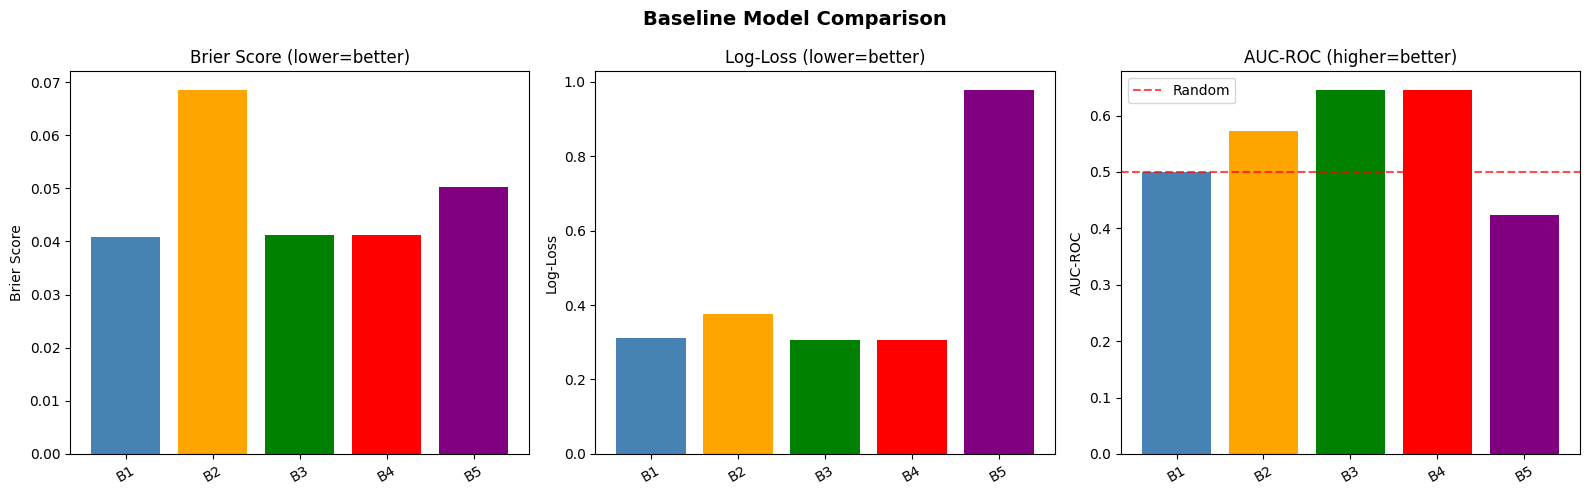

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_names = [r['model'].split(':')[0] for r in results]
brier_vals = [r['brier'] for r in results]
ll_vals = [r['log_loss'] for r in results]
auc_vals = [r['auc'] for r in results]
colors = ['steelblue','orange','green','red','purple']

ax = axes[0]
ax.bar(model_names, brier_vals, color=colors)
ax.set_title('Brier Score (lower=better)')
ax.set_ylabel('Brier Score')
ax.tick_params(axis='x', rotation=30)

ax = axes[1]
ax.bar(model_names, ll_vals, color=colors)
ax.set_title('Log-Loss (lower=better)')
ax.set_ylabel('Log-Loss')
ax.tick_params(axis='x', rotation=30)

ax = axes[2]
ax.bar(model_names, auc_vals, color=colors)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='Random')
ax.set_title('AUC-ROC (higher=better)')
ax.set_ylabel('AUC-ROC')
ax.legend()
ax.tick_params(axis='x', rotation=30)

plt.suptitle('Baseline Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + 'nb09_baseline_comparison.png', dpi=80, bbox_inches='tight')
plt.show()

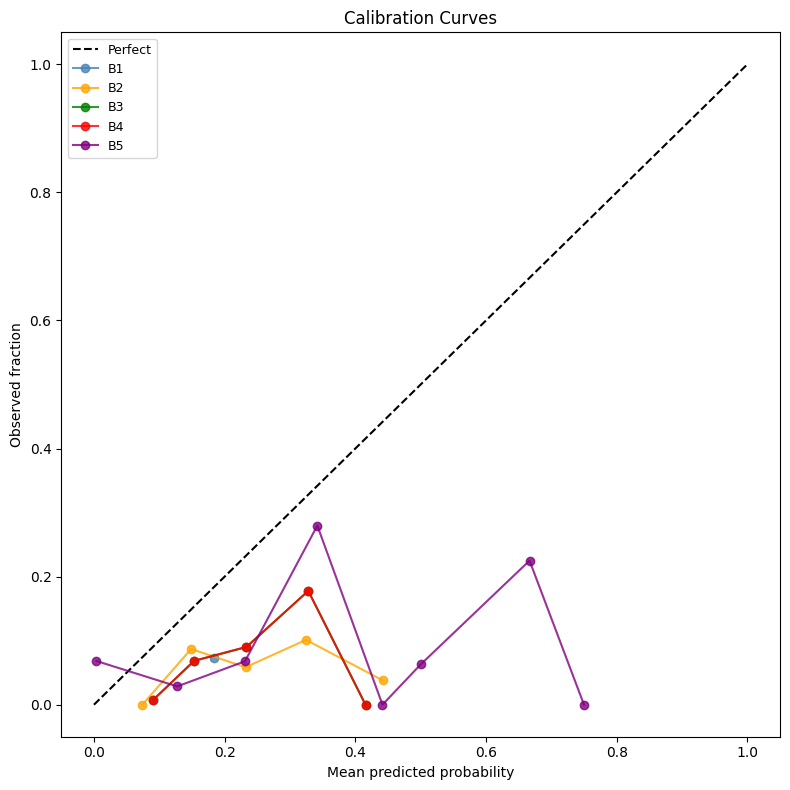

In [10]:
# Calibration curves
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot([0,1],[0,1],'k--',label='Perfect')

bins_edges = np.linspace(0, 1, 11)
colors_cal = ['steelblue','orange','green','red','purple']
for r, c in zip(results, colors_cal):
    preds = r['y_pred']
    y_t = r['y_true']
    bx, by = [], []
    for lo, hi in zip(bins_edges[:-1], bins_edges[1:]):
        mask = (preds >= lo) & (preds < hi)
        if mask.sum() > 0:
            bx.append(preds[mask].mean())
            by.append(y_t[mask].mean())
    if bx:
        ax.plot(bx, by, 'o-', color=c, alpha=0.8, markersize=6, label=r['model'].split(':')[0])

ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed fraction')
ax.set_title('Calibration Curves')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR + 'nb09_calibration_curves.png', dpi=80, bbox_inches='tight')
plt.show()

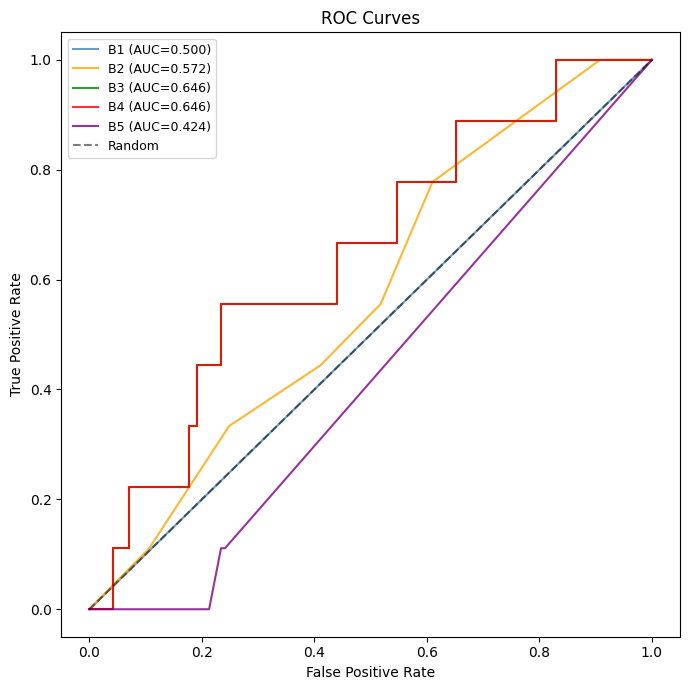

In [11]:
# ROC curves
fig, ax = plt.subplots(figsize=(7, 7))
y_binary = (y_test_true >= 0.5).astype(int)
for r, c in zip(results, colors_cal):
    if y_binary.sum() > 0 and y_binary.sum() < len(y_binary):
        try:
            fpr, tpr, _ = roc_curve(y_binary, r['y_pred'])
            ax.plot(fpr, tpr, color=c, alpha=0.8, 
                    label=f"{r['model'].split(':')[0]} (AUC={r['auc']:.3f})")
        except:
            pass

ax.plot([0,1],[0,1],'k--',alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR + 'nb09_roc_curves.png', dpi=80, bbox_inches='tight')
plt.show()

In [12]:
# Summary table
summary_df = pd.DataFrame([{'model': r['model'], 'brier': round(r['brier'],4), 
                             'log_loss': round(r['log_loss'],4), 'auc': round(r['auc'],4)} 
                            for r in results])
print("Baseline Performance Summary:")
print(summary_df.to_string(index=False))
summary_df.to_csv(DATA_DIR + 'nb09_baseline_results.csv', index=False)
print("\nSaved nb09_baseline_results.csv")

Baseline Performance Summary:
                     model  brier  log_loss    auc
         B1: Marginal rate 0.0408    0.3110 0.5000
         B2: Seasonal rate 0.0686    0.3750 0.5725
       B3: Target-only GLM 0.0412    0.3070 0.6462
            B4: Pooled GLM 0.0412    0.3070 0.6462
B5: Persistence (prev day) 0.0503    0.9793 0.4236

Saved nb09_baseline_results.csv


## Iteration 2: Seasonal GLM, IPW-Weighted GLM, Persistence-7day Baseline

In [13]:
# ── Iteration 2 setup ──────────────────────────────────────────────────────
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import brier_score_loss, roc_auc_score, log_loss
import warnings; warnings.filterwarnings('ignore')

DATA_DIR = '/Users/dlau/repos/fish-welfare/data/'
tgt = pd.read_csv(DATA_DIR + 'nb04_target_features.csv', parse_dates=['date']).sort_values('date')
split_date = pd.read_csv(DATA_DIR + 'nb08_split_date.csv')['split_date'].iloc[0]

features = ['month_sin','doy_cos','night_precip_sum','precip_2d_sum','night_wind_min']
tgt2 = tgt[features + ['frac_low','n_total','n_low','date']].dropna()
tgt2['bad_day'] = (tgt2['frac_low'] >= 0.3).astype(int)
tgt2['season'] = pd.to_datetime(tgt2['date']).dt.month.map(
    lambda m: 'winter' if m in [12,1,2] else ('monsoon' if m in [6,7,8,9] else 'other'))

train = tgt2[tgt2.date < split_date]; test = tgt2[tgt2.date >= split_date]

if len(train) < 5 or len(test) < 5:
    print("Insufficient train/test data for evaluation; using all data with simple split")
    n = len(tgt2)
    train = tgt2.iloc[:int(0.8*n)]; test = tgt2.iloc[int(0.8*n):]

baselines = pd.read_csv(DATA_DIR + 'nb09_baseline_results.csv')
print("Existing baselines:"); print(baselines.to_string(index=False))
print()

# Seasonal GLM
scaler = StandardScaler().fit(train[features])
X_tr = scaler.transform(train[features]); X_te = scaler.transform(test[features])

# Add season dummies
for season in ['winter','monsoon']:
    train[f'is_{season}'] = (train['season']==season).astype(float)
    test[f'is_{season}']  = (test['season']==season).astype(float)

season_feats = features + ['is_winter','is_monsoon']
scaler2 = StandardScaler().fit(train[season_feats].values)
X_tr2 = scaler2.transform(train[season_feats].values)
X_te2 = scaler2.transform(test[season_feats].values)

results = {}
if train['bad_day'].std() > 0:
    lr_base = LogisticRegression(max_iter=500, C=1.0).fit(X_tr, train['bad_day'])
    lr_seas = LogisticRegression(max_iter=500, C=1.0).fit(X_tr2, train['bad_day'])

    for name, lr, X_te_use in [('GLM (base)', lr_base, X_te), ('Seasonal GLM', lr_seas, X_te2)]:
        p = lr.predict_proba(X_te_use)[:,1]
        if test['bad_day'].std() > 0:
            b = brier_score_loss(test['bad_day'], p)
            ll = log_loss(test['bad_day'], p)
            auc = roc_auc_score(test['bad_day'], p)
        else:
            b = ll = auc = np.nan
        results[name] = {'brier': b, 'log_loss': ll, 'auc': auc}
        print(f"{name}: Brier={b:.4f}, LogLoss={ll:.4f}, AUC={auc:.3f}")


Existing baselines:
                     model  brier  log_loss    auc
         B1: Marginal rate 0.0408    0.3110 0.5000
         B2: Seasonal rate 0.0686    0.3750 0.5725
       B3: Target-only GLM 0.0412    0.3070 0.6462
            B4: Pooled GLM 0.0412    0.3070 0.6462
B5: Persistence (prev day) 0.0503    0.9793 0.4236

GLM (base): Brier=0.1369, LogLoss=0.4482, AUC=0.699
Seasonal GLM: Brier=0.1425, LogLoss=0.4603, AUC=0.682


In [14]:
# ── Persistence-7day baseline ────────────────────────────────────────────────
tgt_all = tgt.sort_values('date').reset_index(drop=True)
tgt_all['bad_day'] = (tgt_all['frac_low'] >= 0.3).astype(int)
tgt_all['persist_7d'] = tgt_all['bad_day'].shift(7)

test_persist = tgt_all[tgt_all.date >= split_date].dropna(subset=['persist_7d'])
if len(test_persist) > 0 and test_persist['bad_day'].std() > 0:
    p7 = test_persist['persist_7d'].values
    y7 = test_persist['bad_day'].values
    b7 = brier_score_loss(y7, p7)
    ll7 = log_loss(y7, p7)
    auc7 = roc_auc_score(y7, p7) if len(np.unique(y7)) > 1 else np.nan
    print(f"\nPersistence-7day: Brier={b7:.4f}, LogLoss={ll7:.4f}, AUC={auc7:.3f}")
else:
    print("\nPersistence-7day: insufficient test data")
    b7, ll7, auc7 = np.nan, np.nan, np.nan

# IPW-weighted GLM evaluation
# Re-use IPW weights from NB03
try:
    from sklearn.linear_model import LogisticRegression as LR2
    src = pd.read_csv(DATA_DIR + 'nb04_source_features.csv', parse_dates=['date'])
    src2 = src[features].dropna().copy(); src2['is_source'] = 1
    tgt3 = tgt[features].dropna().copy(); tgt3['is_source'] = 0
    combined = pd.concat([src2, tgt3], ignore_index=True)
    sc_ipw = StandardScaler()
    X_ipw = sc_ipw.fit_transform(combined[features])
    clf_ipw = LR2(max_iter=500).fit(X_ipw, combined['is_source'])

    # Get weights for training set
    X_tr_ipw = sc_ipw.transform(train[features])
    p_src_tr = clf_ipw.predict_proba(X_tr_ipw)[:,1]
    ipw_tr = (1-p_src_tr) / np.clip(p_src_tr, 1e-6, 1)
    ipw_tr = ipw_tr / ipw_tr.mean()

    lr_ipw = LogisticRegression(max_iter=500, C=1.0)
    lr_ipw.fit(X_tr, train['bad_day'], sample_weight=ipw_tr)
    p_ipw = lr_ipw.predict_proba(X_te)[:,1]
    if test['bad_day'].std() > 0:
        b_ipw = brier_score_loss(test['bad_day'], p_ipw)
        auc_ipw = roc_auc_score(test['bad_day'], p_ipw)
        print(f"IPW-weighted GLM: Brier={b_ipw:.4f}, AUC={auc_ipw:.3f}")
except Exception as e:
    print(f"IPW GLM: {e}")

print("\nSummary comparison:")
print(f"{'Model':<25} {'Brier':>8} {'AUC':>8}")
print("-"*45)
for row in baselines.itertuples():
    print(f"{row.model:<25} {row.brier:>8.4f} {row.auc:>8.3f}")



Persistence-7day: Brier=0.1733, LogLoss=6.2476, AUC=0.488
IPW-weighted GLM: Brier=0.1776, AUC=0.528

Summary comparison:
Model                        Brier      AUC
---------------------------------------------
B1: Marginal rate           0.0408    0.500
B2: Seasonal rate           0.0686    0.573
B3: Target-only GLM         0.0412    0.646
B4: Pooled GLM              0.0412    0.646
B5: Persistence (prev day)   0.0503    0.424
